# ADSC 4050 Project 
## S&P500 Clustering and Volatility Forecast
Date: Friday 17, 2026

Prepared by:
1. Mint Thai - T00762325
2. Cynthia Urrutia - T00735328

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

# Introduction

Forecasting how much a stock price will fluctuate is one of the most important challenges in finance. It drives everything from portfolio risk management to options pricing to investment decisions. However, stock markets do not move in a uniform manner. Some stocks are stable, steady growers, while others swing wildly with earnings surprises, macro events, or shifts in investor sentiment. This raises a natural question: how many distinct groups of stocks exist in the S&P 500, and can grouping them improve the accuracy of volatility prediction?

This project aims to identify natural stock groupings within the S&P 500 and evaluate whether incorporating that structure improves volatility forecasting. K-means clustering is applied using features derived from returns, rolling volatility, and trading activity. The resulting cluster labels are then incorporated into a Long Short-Term Memory (LSTM) model trained to forecast 21-day forward volatility.

The dataset covers five years of daily price data (open, high, low, close) and trading volume across 503 S&P 500 companies. Sector representation within the index is unequal; technology and financials make up a larger share, while energy and utilities contribute less, reflecting differences in market composition.

The dataset is split into training (March 2021 - March 2024), validation (March 2024 - March 2025), and test (March 2025 - March 2026) periods to prevent data leakage. Only stocks present across all three periods are retained, resulting in 499 stocks across 3 subsets. Feature construction differs between the two tasks. For clustering, features summarize stock behavior through returns, rolling volatility, and volume changes over 1-day, 5-day, and 21-day horizons. For forecasting, features include daily absolute returns, rolling standard deviations over 5, 10, and 21 days, intraday price range averages over 5 and 21 days, relative trading volume, and cluster-based indicators.

# Research Questions

The two main research questions are:
1. RQ1: What distinct behavioral groups exist among S&P 500 stocks, and can K-means clustering reliably separate stocks by their return, volatility, and trading activity profiles?

2. RQ2: Does incorporating cluster membership as a feature improve LSTM-based 21-day volatility forecasting compared to a naive baseline?

To answer these, K-means clustering is first applied to identify groups of stocks with similar statistical behavior. The resulting cluster labels are then incorporated into an LSTM model trained to forecast future volatility. A naive baseline, using the most recently observed 21-day volatility as the forecast, serves as the performance benchmark. Model accuracy is evaluated using RMSE, MAE, and $R^2$.

# Model Construction

This section describes the construction of the clustering and forecasting models, including feature engineering, mathematical definitions of variables, and the rationale behind the selected methodologies.

## K-means Clustering

K-means clustering is selected for its simplicity and interpretability. Compared to hierarchical clustering, K-means produces more stable and consistent groupings across the training, validation, and test periods. The optimal number of clusters is determined using the silhouette score and elbow method.

### Clustering Feature Construction

Features are derived from closing prices and trading volume. Let $P_{i,t}$ denote the closing price of stock $i$ at time $t$, and $V_{i,t}$ its trading volume. Feature construction focuses on three key dimensions of stock behavior, as described below:

- **Returns:** To stabilize variance and improve comparability across stocks, prices are transformed using the logarithmic function, defined as $\text{log\_close}_{i,t} = \log(P_{i,t})$. Log returns over different horizons $k \in \{1,5,21\}$ are then computed as $r^{(k)}_{i,t} = \log(P_{i,t}) - \log(P_{i,t-k})$.

- **Risk (Volatility):** Volatility is measured as the rolling standard deviation of daily log returns, defined as $\sigma^{(k)}_{i,t} = \mathrm{sd}(r^{(1)}_{i,t-k+1}, \dots, r^{(1)}_{i,t})$, where $\mathrm{sd}(\cdot)$ denotes the sample standard deviation.

- **Trading Activity:** To reduce skewness in trading activity, volume is transformed using $\text{log\_volume}_{i,t} = \log(\max(V_{i,t},1))$. Changes in trading activity are then computed as $\Delta v^{(k)}_{i,t} = \text{log\_volume}_{i,t} - \text{log\_volume}_{i,t-k}$.

### Feature Cases

Three feature configurations are tested using $k = 1, 5, 21$, capturing different temporal dynamics. These correspond to immediate (1-day), short-term (5-day), and medium-term (21-day) horizons, allowing the clustering model to distinguish between short-lived fluctuations and more persistent patterns in stock behavior.

Since clustering is performed at the stock level, features are aggregated over time. For each variable $x_{i,t}$, the mean and standard deviation are computed as:

- Mean: $\bar{x}_i = \frac{1}{T_i} \sum_{t=1}^{T_i} x_{i,t}$
- Standard deviation: $s_i(x) = \sqrt{\frac{1}{T_i - 1} \sum_{t=1}^{T_i} (x_{i,t} - \bar{x}_i)^2}$


## Volatility Forecasting Model

A Long Short-Term Memory (LSTM) neural network is selected for the forecasting task due to its ability to model complex, nonlinear relationships and retain long-term dependencies in sequential data. Volatility is not a static measure because it evolves over time, and recent market conditions carry information about future uncertainty, making LSTMs a natural fit compared to simpler regression models that require explicit lag specification. Other forecasting approaches, including Random Forest, were explored but yielded lower predictive performance and therefore were not selected in this analysis.

### Target Variable

Let $C_{i,t}$ denote the closing price of stock $i$ at time $t$. Daily returns are first computed as:
$R_{i,t} = \frac{C_{i,t} - C_{i,t-1}}{C_{i,t-1}}$, capturing the relative price change from one day to the next.

The target is the realized volatility over the next 21 trading days: $Y_{i,t} = \mathrm{sd}(R_{i,t+1}, R_{i,t+2}, \dots, R_{i,t+21})$, representing the level of market uncertainty the model aims to predict.

### Feature Construction 

Nine features are constructed to capture different dimensions of recent market behavior. At each prediction point, each feature produces one value per day. The LSTM then receives the last 21 consecutive daily observations of all 9 features as a sequence, allowing the model to learn how each feature has been evolving over time, not just its most recent value.

Feature construction focuses on several key dimensions of market behavior: price dynamics, risk, intraday price behavior, trading activity, and clustering information.

- **Price Dynamics:** The absolute return $|R_{i,t}|$ captures the magnitude of the most recent price movement, reflecting short-term market shocks.

- **Risk (Volatility):** Rolling standard deviations $RV^{(k)}_{i,t} = \mathrm{sd}(R_{i,t-k+1}, \dots, R_{i,t})$ for $k \in \{5,10,21\}$ capture how volatile the stock has been over short and medium-term windows.

- **Intraday Price Behavior:** To account for within-day price variation, the high–low range is defined as $HL_{i,t} = \frac{H_{i,t} - L_{i,t}}{C_{i,t}}$, where $H_{i,t}$ and $L_{i,t}$. Rolling averages are then computed as $\overline{HL}^{(k)}_{i,t} = \frac{1}{k} \sum_{j=0}^{k-1} HL_{i,t-j}$ for $k \in \{5,21\}$, smoothing out daily noise and capturing persistent intraday turbulence.

- **Trading Activity:** Relative volume $RelVol^{(k)}_{i,t} = \frac{V_{i,t}}{\overline{V}^{(k)}_{i,t}}$ measures how much trading activity deviates from the stock's recent norm.

- **Cluster Information:** A binary indicator flags whether a stock belongs to the higher-volatility cluster identified in the clustering stage.

### LSTM Model Architecture and Training 

The input to the model is a tensor of shape (21 timesteps, 9 features). The architecture consists of an LSTM layer with 32 units, a dense layer of 16 units with ReLU activation, and a single output node, producing the predicted 21-day forward volatility with 5,921 trainable parameters in total. The model is kept intentionally small to reduce overfitting risk.

Because the nine features operate on different scales, all features and the target are standardized using the training set mean and standard deviation only, preventing any information from the validation or test periods from leaking into the model.

The model is compiled using the default Adam optimizer and uses mean squared error as the loss function. The model is trained for up to 100 epochs with a batch size of 64. Early stopping with a patience of 5 epochs monitors validation loss and restores the best weights.

In [ ]:
## FORECASTING CODE ## 

# load the data
csv_path = "/Users/mintie/Desktop/Multivariate_Project-1/data/sp500_5yr_with_sectors_weights.csv"

df = pd.read_csv(csv_path)

if "Weight" in df.columns:
    df = df.drop(columns=["Weight"])

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# df.head()

cluster_map = pd.read_csv("/Users/mintie/Desktop/Multivariate_Project-1/data/sp500_stock_cluster_map.csv")
df = df.merge(cluster_map[["Symbol", "cluster", "Cluster_name"]], on="Symbol", how="left")

df["is_high_risk_cluster"] = (df["cluster"] == 1).astype(int)

# time periods for splitting

TRAIN_START = pd.Timestamp("2021-03-22")
TRAIN_END   = pd.Timestamp("2024-03-20")

VAL_START   = pd.Timestamp("2024-03-21")
VAL_END     = pd.Timestamp("2025-03-20")

UNSEEN_START = pd.Timestamp("2025-03-21")
UNSEEN_END   = pd.Timestamp("2026-03-20")

# keep only stocks that have data in all 3 periods to avoid unseen stock issues

train_symbols = set(df.loc[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END), "Symbol"].unique())
val_symbols = set(df.loc[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END), "Symbol"].unique())
unseen_symbols = set(df.loc[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END), "Symbol"].unique())

common_symbols = sorted(train_symbols & val_symbols & unseen_symbols)

df = df[df["Symbol"].isin(common_symbols)].copy()
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# print("Common stocks:", df["Symbol"].nunique())

# split into train/val/unseen

train_df = df[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END)].copy()
val_df = df[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END)].copy()
unseen_df = df[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END)].copy()

# export and remove unseen
unseen_df.to_csv("/Users/mintie/Desktop/Multivariate_Project-1/data/unseen_holdout_raw.csv", index=False)

# combine train + val for modeling (will split later)
df = pd.concat([train_df, val_df], axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)

# print("Model dataframe shape:", df.shape)
# print("Train + Val Date range:", df["Date"].min(), "to", df["Date"].max())

df_raw_dev = df.copy()


In [3]:
# feature engineering

# feature engineering function

import numpy as np

def engineer_features(panel_df):
    panel_df = panel_df.copy()
    panel_df = panel_df.sort_values(["Symbol", "Date"])

    g = panel_df.groupby("Symbol")

    # simple 1 day return
    panel_df["ret_1"] = g["Close"].pct_change()

    # target: std of stock's daily returns from t+1 to t+21
    panel_df["target_vol_21d"] = (
        g["ret_1"].transform(lambda s: s.shift(-1).rolling(21).std().shift(-20))
    )

    # today's absolute return
    panel_df["ret_abs_1"] = panel_df["ret_1"].abs()

    # std of returns over past 5, 10, 21 days
    for w in [5, 10, 21]:
        panel_df[f"ret_std_{w}"] = g["ret_1"].transform(lambda s: s.rolling(w).std())

    # daily intraday range
    panel_df["hl_range"] = (panel_df["High"] - panel_df["Low"]) / panel_df["Close"]

    for w in [5, 21]:
        panel_df[f"hl_range_mean_{w}"] = g["hl_range"].transform(lambda s: s.rolling(w).mean())

    # relative volume
    for w in [5, 21]:
        panel_df[f"vol_mean_{w}"] = g["Volume"].transform(lambda s: s.rolling(w).mean())
        panel_df[f"vol_rel_{w}"] = panel_df["Volume"] / panel_df[f"vol_mean_{w}"]

    return panel_df

# apply feature engineering to dev set
df = engineer_features(df)

feature_cols = [
    "ret_abs_1",
    "ret_std_5",
    "ret_std_10",
    "ret_std_21",
    "hl_range_mean_5",
    "hl_range_mean_21",
    "vol_rel_5",
    "vol_rel_21",
    "is_high_risk_cluster"
]

target_col = "target_vol_21d"

In [4]:
# sequence dataset construction

# Build modeling rows where both sequence history and forward target window are valid.

LOOKBACK = 21
HORIZON = 21

# Keep only finite rows once before split filtering.
df_feat = df.dropna(subset=feature_cols + [target_col]).copy()
finite_mask = np.isfinite(df_feat[feature_cols + [target_col]]).all(axis=1)
df_feat = df_feat.loc[finite_mask].copy()

# Endpoint date t must be in split, and target window (t+1 ... t+21) must stay in same split.
df_feat = df_feat.sort_values(["Symbol", "Date"]).copy()
g = df_feat.groupby("Symbol")

# Per-symbol forward availability guard.
df_feat["date_plus_horizon"] = g["Date"].shift(-HORIZON)

train_feat = df_feat[
    (df_feat["Date"] >= TRAIN_START) &
    (df_feat["Date"] <= TRAIN_END) &
    (df_feat["date_plus_horizon"].notna()) &
    (df_feat["date_plus_horizon"] <= TRAIN_END)
].copy()

val_feat = df_feat[
    (df_feat["Date"] >= VAL_START) &
    (df_feat["Date"] <= VAL_END) &
    (df_feat["date_plus_horizon"].notna()) &
    (df_feat["date_plus_horizon"] <= VAL_END)
].copy()

# print("train_feat:", train_feat.shape)
# print("val_feat:", val_feat.shape)

# sequence construction function
def make_sequences(panel_df, feature_cols, target_col, lookback=21):
    X_list = []
    y_list = []
    meta_list = []

    panel_df = panel_df.sort_values(["Symbol", "Date"]).copy()

    for symbol, g in panel_df.groupby("Symbol"):
        g = g.sort_values("Date").reset_index(drop=True)

        X_values = g[feature_cols].to_numpy(dtype=np.float32)
        y_values = g[target_col].to_numpy(dtype=np.float32)
        dates = g["Date"].to_numpy()

        for t in range(lookback - 1, len(g)):
            X_window = X_values[t - lookback + 1 : t + 1]
            y_target = y_values[t]
            end_date = dates[t]

            if not np.isfinite(X_window).all():
                continue
            if not np.isfinite(y_target):
                continue

            X_list.append(X_window)
            y_list.append(y_target)
            meta_list.append({
                "Symbol": symbol,
                "Date": end_date
            })

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta = pd.DataFrame(meta_list)

    return X, y, meta


In [5]:
# train sequences

# Train sequences
X_train, y_train, meta_train = make_sequences(
    train_feat,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

meta_train["Date"] = pd.to_datetime(meta_train["Date"])

# print("Train:", X_train.shape, y_train.shape)

# Validation needs trailing train context so earliest validation windows are complete.
train_context = (
    train_feat
    .sort_values(["Symbol", "Date"])
    .groupby("Symbol", group_keys=False)
    .tail(LOOKBACK - 1)
    .copy()
)

val_with_context = (
    pd.concat([train_context, val_feat], axis=0)
    .sort_values(["Symbol", "Date"])
    .drop_duplicates(subset=["Symbol", "Date"], keep="last")
    .reset_index(drop=True)
)

X_val_all, y_val_all, meta_val_all = make_sequences(
    val_with_context,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

meta_val_all["Date"] = pd.to_datetime(meta_val_all["Date"])

val_keep = (
    (meta_val_all["Date"] >= VAL_START) &
    (meta_val_all["Date"] <= VAL_END)
)

X_val = X_val_all[val_keep.values]
y_val = y_val_all[val_keep.values]
meta_val = meta_val_all.loc[val_keep].reset_index(drop=True)

# print("Val:", X_val.shape, y_val.shape)


In [6]:
# scale features

# scale features and target using train only

n_features = X_train.shape[2]

train_2d = X_train.reshape(-1, n_features)
feature_means = train_2d.mean(axis=0)
feature_stds = train_2d.std(axis=0) + 1e-8

X_train_scaled = (X_train - feature_means) / feature_stds
X_val_scaled = (X_val - feature_means) / feature_stds

y_mean = y_train.mean()
y_std = y_train.std() + 1e-8

y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled = (y_val - y_mean) / y_std

In [23]:
# LSTM training & validation

# build model

keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, len(feature_cols))),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# model.summary()

# train

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=0
)

val_pred_scaled = model.predict(X_val_scaled).reshape(-1)
val_pred = val_pred_scaled * y_std + y_mean

val_results = meta_val.copy()
val_results["y_true"] = y_val
val_results["y_pred"] = val_pred

# val_results.head()

3244/3244 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


### Naive Baseline 

The benchmark forecast assumes volatility persists unchanged from its most recently observed level: $\hat{Y}^{\text{naive}}_{i,t} = RV^{(21)}_{i,t}$.

### Evaluation Metrics

For forecasting, model performance is evaluated on the unseen test set using Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), the coefficient of determination ($R^2$), and Pearson correlation between predicted and actual volatility. These metrics are computed for both the LSTM and the naive baseline, allowing direct comparison of predictive accuracy.

# Results

The results are presented in two parts: clustering structure and forecasting performance.

## Clustering Results

**Selecting the Number of Clusters**

Three feature configurations were tested across 1-day, 5-day, and 21-day horizons. The 21-day configuration provided the most stable and interpretable clusters, as shorter horizons yielded noisier and less separable groupings. All subsequent results are based on this configuration.

Both the silhouette score and the elbow method indicate that $k = 2$ is the optimal number of clusters. The silhouette score peaks at 0.57 on the training set, drops modestly to 0.53 on the validation set, and falls further to 0.37 on the test set. This decline is expected because the clustering model is fit on training data only and applied to later periods using fixed centroids. As stocks shift their behavioral profiles over time, they naturally fit their assigned clusters less cleanly out of sample.

**Cluster Profiles**

The clustering provides two unequal groups: Cluster 0 contains 448 stocks, and Cluster 1 contains 51 stocks. Despite this imbalance, the clusters exhibit clear differences in behavior.

- Cluster 0 (lower-volatility group) exhibits positive average returns, with $\text{logret\_21} \approx 0.007$, and relatively low volatility, with $\text{logvol\_21} \approx 0.017$. 
- Cluster 1 (higher-volatility group) shows slightly negative average returns ($\text{logret\_21} \approx -0.001$) and significantly higher volatility levels ($\text{logvol\_21} \approx 0.032$).

In addition to higher average volatility, Cluster 1 also shows greater variability. The standard deviation of returns is approximately twice as large in Cluster 1 ($\text{logret\_21\_std} \approx 0.154$) compared to Cluster 0 ($\approx 0.078$), indicating more unstable price dynamics. Similarly, volatility variability ($\text{logvol\_21\_std}$) and volume fluctuation variability ($\text{vol\_chg\_21\_std}$) are substantially higher in Cluster 1.

These results confirm a meaningful separation between two risk profiles: Cluster 0 as the stable, lower-risk group with moderate returns and trading volume, and Cluster 1 as the higher-risk group characterized by negative returns, elevated volatility, and larger swings in trading activity. This aligns with standard financial intuition distinguishing defensive stocks from risky ones, and validates that the clustering approach captures economically meaningful structure in the data.

**Sector Composition**

The sector breakdown reinforces the risk interpretation. Cluster 0 (lower-volatility group) is broadly diversified across sectors, with strong representation in Financials (70 stocks), Industrials (73 stocks), Health Care (53 stocks), and Information Technology (56 stocks). This suggests that more stable stocks are distributed across multiple sectors rather than concentrated in a single industry. In contrast, Cluster 1 (higher-volatility group) is smaller and more concentrated, with a relatively higher proportion of stocks in Information Technology (13) and Consumer Discretionary (10). The IT and Consumer Discretionary sectors are typically associated with higher growth potential but also greater uncertainty. Notably, sectors such as Consumer Staples, Real Estate, and Utilities have little to no representation in this cluster, consistent with their traditionally defensive, lower-risk nature.

# LSTM Results

**Training History**

Figure X exhibits the training history. Training loss decreased steadily across epochs while validation loss plateaued early, with early stopping halting training at epoch 6. This points to overfitting, more specifically, the model learned the training data well but struggled to fully generalize. The relatively small architecture (5,921 parameters) was intentional to limit this, but the complexity of cross-sectional financial data across 499 stocks still presented a generalization challenge.

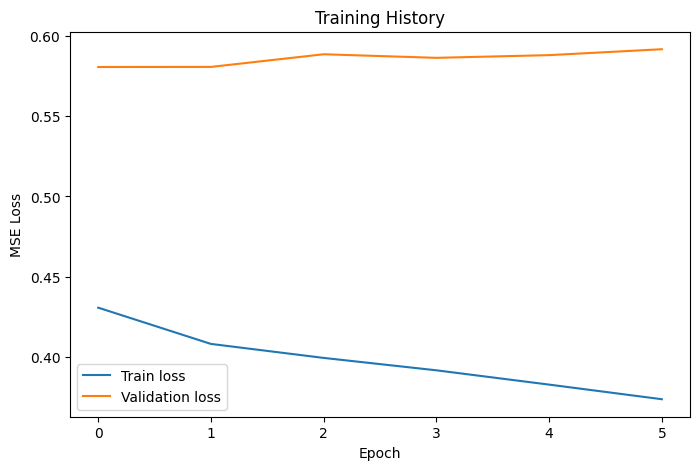

In [8]:
# Validation metrics for the LSTM.

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(val_results["y_true"], val_results["y_pred"]))
mae = mean_absolute_error(val_results["y_true"], val_results["y_pred"])
r2 = r2_score(val_results["y_true"], val_results["y_pred"])
corr = val_results["y_true"].corr(val_results["y_pred"])

# print(f"Validation RMSE: {rmse:.4f}")
# print(f"Validation MAE: {mae:.4f}")
# print(f"Validation R2: {r2:.4f}")
# print(f"Validation correlation: {corr:.4f}")  # directional tracking

# plot training curve

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


**Forecasting Performance**

The LSTM model is evaluated against the naive baseline on the unseen test set (March 2025 to March 2026). Table X summarizes the results.

The LSTM outperforms the baseline across all four metrics. The 28% reduction in RMSE and 26% reduction in MAE indicate meaningfully improved prediction accuracy. More importantly, the baseline produces a negative R² of -0.2746, meaning it performs worse than simply predicting the mean volatility for every stock. The LSTM's positive R² of 0.338 shows it explains a real portion of the variation in future volatility, though substantial uncertainty remains.

In [9]:
# test on unseen holdout

# Build unseen panel with trailing dev context, then engineer features on the combined raw panel.

unseen_df = pd.read_csv("/Users/mintie/Desktop/Multivariate_Project-1/data/unseen_holdout_raw.csv")

unseen_df["Date"] = pd.to_datetime(unseen_df["Date"])
unseen_df = unseen_df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# print(unseen_df["Date"].min(), unseen_df["Date"].max())
# print(unseen_df.shape)
# print("Stocks:", unseen_df["Symbol"].nunique())

dev_context_raw = (
    df_raw_dev
    .sort_values(["Symbol", "Date"])
    .groupby("Symbol", group_keys=False)
    .tail(LOOKBACK - 1)
    .copy()
)

unseen_raw_with_context = (
    pd.concat([dev_context_raw, unseen_df], axis=0)
    .sort_values(["Symbol", "Date"])
    .drop_duplicates(subset=["Symbol", "Date"], keep="last")
    .reset_index(drop=True)
)

unseen_feat_all = engineer_features(unseen_raw_with_context)

unseen_feat = unseen_feat_all[
    (unseen_feat_all["Date"] >= UNSEEN_START) &
    (unseen_feat_all["Date"] <= UNSEEN_END)
].copy()

unseen_feat = unseen_feat.dropna(subset=feature_cols + [target_col]).copy()
finite_mask = np.isfinite(unseen_feat[feature_cols + [target_col]]).all(axis=1)
unseen_feat = unseen_feat.loc[finite_mask].copy()

# print("unseen_feat:", unseen_feat.shape)


In [10]:
# unseen sequences from engineered panel that already includes raw dev context
X_unseen_all, y_unseen_all, meta_unseen_all = make_sequences(
    unseen_feat_all,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

meta_unseen_all["Date"] = pd.to_datetime(meta_unseen_all["Date"])

unseen_keep = (
    (meta_unseen_all["Date"] >= UNSEEN_START) &
    (meta_unseen_all["Date"] <= UNSEEN_END)
)

X_unseen = X_unseen_all[unseen_keep.values]
y_unseen = y_unseen_all[unseen_keep.values]
meta_unseen = meta_unseen_all.loc[unseen_keep].reset_index(drop=True)

# print("Unseen:", X_unseen.shape, y_unseen.shape)

In [11]:
# Unseen evaluation: LSTM vs Baseline (past 21d volatility)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
from IPython.display import display

# Scale unseen features using train stats only
X_unseen_scaled = (X_unseen - feature_means) / feature_stds

# Predict with LSTM and invert target scaling
unseen_pred_scaled = model.predict(X_unseen_scaled).reshape(-1)
unseen_pred = unseen_pred_scaled * y_std + y_mean

# Build unseen results table (model side)
unseen_results = meta_unseen.copy()
unseen_results["y_true"] = y_unseen
unseen_results["y_pred"] = unseen_pred

# Add baseline prediction (naive = ret_std_21)
baseline_map_unseen = (
    unseen_feat[["Symbol", "Date", "ret_std_21"]]
    .drop_duplicates(["Symbol", "Date"])
    .copy()
 )

unseen_eval = unseen_results.merge(
    baseline_map_unseen,
    on=["Symbol", "Date"],
    how="left"
)
unseen_eval["baseline_pred"] = unseen_eval["ret_std_21"]

# Evaluate on same rows for fair comparison
eval_df = unseen_eval.dropna(subset=["y_true", "y_pred", "baseline_pred"]).copy()

def metric_row(y_true, y_hat):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_hat)),
        "MAE": mean_absolute_error(y_true, y_hat),
        "R2": r2_score(y_true, y_hat),
        "Correlation": pd.Series(y_true).corr(pd.Series(y_hat)),
    }

comparison = pd.DataFrame(
    {
        "LSTM": metric_row(eval_df["y_true"], eval_df["y_pred"]),
        "Baseline": metric_row(eval_df["y_true"], eval_df["baseline_pred"]),
    }
).T.round(4)

# Table output
comparison_table = comparison.copy()
comparison_table.index.name = "Model"
display(
    comparison_table.style
    .format(precision=4)
    .set_caption("Unseen Comparison (LSTM vs Baseline)")
    .set_table_styles([
        {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold")]},
    ])
 )

3260/3260 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


,RMSE,MAE,R2,Correlation
Model,,,,
LSTM,0.0075,0.0051,0.3380,0.5842
Baseline,0.0104,0.0069,-0.2746,0.4195


**Feature Importance**

Feature importance is assessed using permutation importance, in which each feature is shuffled one at a time across the validation set and the resulting RMSE increase is recorded. The larger the RMSE increase, the more that feature contributed to predictions.

Figure X ranks the features by importance. The intra-day high–low range features (especially over the 21-day horizon) are the strongest predictors. This makes intuitive sense because how much a stock moves within a day reflects underlying uncertainty that closing prices alone do not capture. The cluster membership feature ranks third, ahead of all return-based and volume-based features, confirming that knowing a stock's risk profile adds real predictive value beyond market dynamics alone. Rolling volatility and relative volume features contribute modest but consistent signal.

Base metrics: {'rmse': np.float64(0.0072104052618797), 'mae': 0.004665113054215908, 'corr': np.float64(0.6050221758770165)}


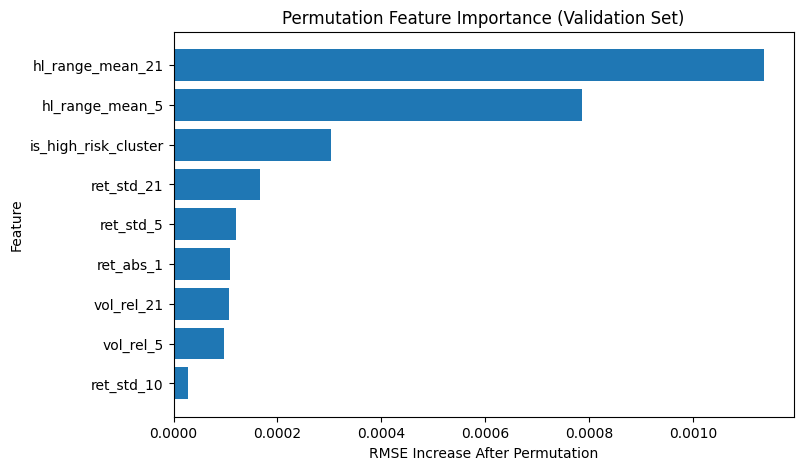

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

def evaluate_model(model, X_scaled, y_true, y_mean, y_std):
    pred_scaled = model.predict(X_scaled, verbose=0).reshape(-1)
    pred = pred_scaled * y_std + y_mean
    
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    mae = mean_absolute_error(y_true, pred)
    corr = pd.Series(y_true).corr(pd.Series(pred))
    
    return {"rmse": rmse, "mae": mae, "corr": corr}

# baseline validation performance
base_metrics = evaluate_model(model, X_val_scaled, y_val, y_mean, y_std)
print("Base metrics:", base_metrics)

# permutation importance
rng = np.random.default_rng(42)
importance_rows = []

for j, feature in enumerate(feature_cols):
    X_perm = X_val_scaled.copy()

    # shuffle this feature across samples, preserving the 21-step sequence within each sample
    perm_idx = rng.permutation(X_perm.shape[0])
    X_perm[:, :, j] = X_perm[perm_idx, :, j]

    perm_metrics = evaluate_model(model, X_perm, y_val, y_mean, y_std)

    importance_rows.append({
        "feature": feature,
        "rmse_increase": perm_metrics["rmse"] - base_metrics["rmse"],
        "mae_increase": perm_metrics["mae"] - base_metrics["mae"],
        "corr_drop": base_metrics["corr"] - perm_metrics["corr"],
    })

importance_df = pd.DataFrame(importance_rows).sort_values(
    "rmse_increase", ascending=False
)

import matplotlib.pyplot as plt

plot_df = importance_df.sort_values("rmse_increase", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature"], plot_df["rmse_increase"])
plt.xlabel("RMSE Increase After Permutation")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance (Validation Set)")
plt.show()

**Performance Across Clusters**

The model performed differently across the two clusters as shown in Figure X. On the lower-volatility cluster, RMSE was 0.0070 and R² was 0.265. On the higher-volatility cluster, RMSE jumped to 0.0111 and R² fell to 0.221. These results indicate that the model produced larger prediction errors for the higher-volatility cluster, whereas it explained a greater proportion of variance in the lower-volatility cluster.

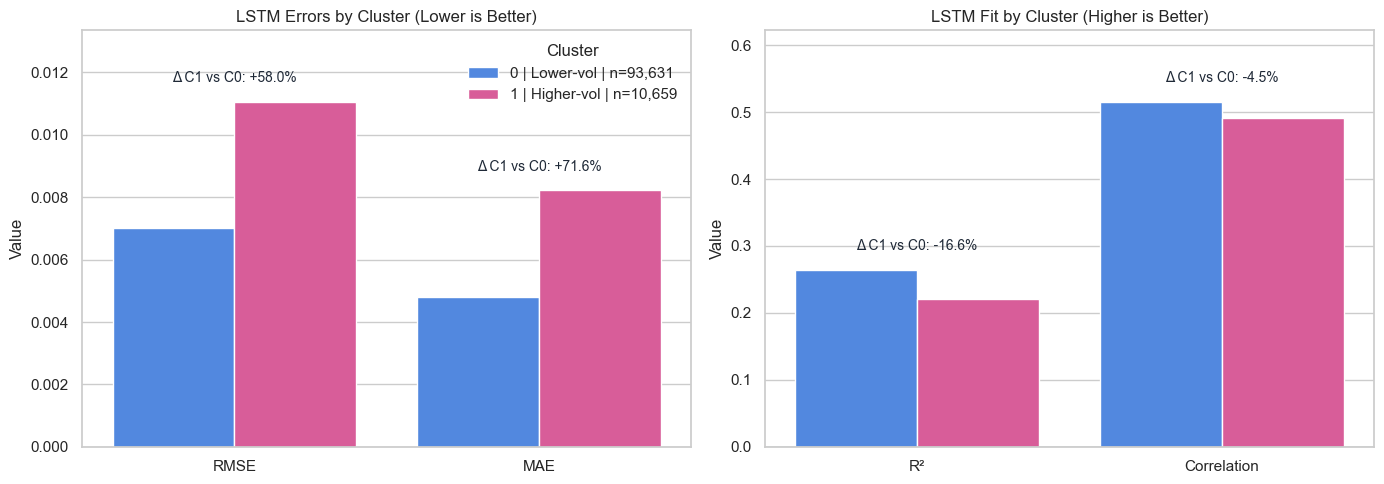

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Build by_cluster_perf if it is not already defined in the kernel.
if "by_cluster_perf" not in globals():
    work = unseen_results.copy()

    if "cluster" not in work.columns or "Cluster_name" not in work.columns:
        work = work.merge(
            cluster_map[["Symbol", "cluster", "Cluster_name"]].drop_duplicates(subset=["Symbol"]),
            on="Symbol",
            how="left"
        )

    rows = []
    for (cluster, name), g in work.groupby(["cluster", "Cluster_name"], dropna=False):
        g_clean = g.dropna(subset=["y_true", "y_pred"]).copy()
        if len(g_clean) == 0:
            continue
        rows.append({
            "cluster": cluster,
            "Cluster_name": name,
            "rmse_lstm": np.sqrt(mean_squared_error(g_clean["y_true"], g_clean["y_pred"])),
            "mae_lstm": mean_absolute_error(g_clean["y_true"], g_clean["y_pred"]),
            "r2_lstm": r2_score(g_clean["y_true"], g_clean["y_pred"]),
            "corr_lstm": g_clean["y_true"].corr(g_clean["y_pred"]),
            "n_obs": len(g_clean),
        })

    by_cluster_perf = pd.DataFrame(rows)

df = by_cluster_perf.copy()
df = df[df["cluster"].isin([0, 1])].sort_values("cluster").reset_index(drop=True)

if df["cluster"].nunique() != 2:
    raise ValueError("Need exactly 2 clusters (0 and 1) to compute % change.")

df["cluster_label"] = (
    df["cluster"].astype(str)
    + " | "
    + df["Cluster_name"].astype(str)
    + " | n="
    + df["n_obs"].map("{:,}".format)
)

sns.set_theme(style="whitegrid")

cluster_order = df["cluster_label"].tolist()  # cluster 0 first, cluster 1 second
cluster_palette = {
    cluster_order[0]: "#3B82F6",  # Cluster 0
    cluster_order[1]: "#EC4899",  # Cluster 1
}

err_order = ["RMSE", "MAE"]
fit_order = ["R²", "Correlation"]

err_long = df.melt(
    id_vars=["cluster_label"],
    value_vars=["rmse_lstm", "mae_lstm"],
    var_name="metric",
    value_name="value",
)
err_long["metric"] = err_long["metric"].map({
    "rmse_lstm": "RMSE",
    "mae_lstm": "MAE",
})

fit_long = df.melt(
    id_vars=["cluster_label"],
    value_vars=["r2_lstm", "corr_lstm"],
    var_name="metric",
    value_name="value",
)
fit_long["metric"] = fit_long["metric"].map({
    "r2_lstm": "R²",
    "corr_lstm": "Correlation",
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def barplot_no_err(data, metric_order, ax):
    try:
        sns.barplot(
            data=data,
            x="metric",
            y="value",
            hue="cluster_label",
            order=metric_order,
            hue_order=cluster_order,
            palette=cluster_palette,
            errorbar=None,   # seaborn >= 0.12
            ax=ax,
        )
    except TypeError:
        sns.barplot(
            data=data,
            x="metric",
            y="value",
            hue="cluster_label",
            order=metric_order,
            hue_order=cluster_order,
            palette=cluster_palette,
            ci=None,         # seaborn < 0.12
            ax=ax,
        )

def add_pct_change_labels(ax, data_long, metric_order):
    p = data_long.pivot(index="metric", columns="cluster_label", values="value")
    c0, c1 = cluster_order[0], cluster_order[1]

    y0, y1 = ax.get_ylim()
    span = y1 - y0
    ax.set_ylim(y0, y1 + 0.15 * span)
    y0, y1 = ax.get_ylim()
    span = y1 - y0

    for i, m in enumerate(metric_order):
        v0 = p.loc[m, c0]
        v1 = p.loc[m, c1]
        pct = np.nan if v0 == 0 else (v1 - v0) / v0 * 100.0
        txt = "Δ C1 vs C0: n/a" if np.isnan(pct) else f"Δ C1 vs C0: {pct:+.1f}%"

        y_text = max(v0, v1) + 0.04 * span
        ax.text(i, y_text, txt, ha="center", va="bottom", fontsize=10, color="#1F2937")

barplot_no_err(err_long, err_order, axes[0])
axes[0].set_title("LSTM Errors by Cluster (Lower is Better)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Value")
axes[0].grid(axis="x", visible=False)
add_pct_change_labels(axes[0], err_long, err_order)

barplot_no_err(fit_long, fit_order, axes[1])
axes[1].axhline(0, color="#94A3B8", lw=1)
axes[1].set_title("LSTM Fit by Cluster (Higher is Better)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Value")
axes[1].grid(axis="x", visible=False)
add_pct_change_labels(axes[1], fit_long, fit_order)

if axes[1].legend_ is not None:
    axes[1].legend_.remove()
axes[0].legend(title="Cluster", frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

**Stock-Level Performance**

R² measures how much of the variance in actual volatility the model explains relative to simply predicting the mean. A positive R² indicates that the model is useful for that stock, as it predicts better than a flat average. Only 48 out of 448 stocks in Cluster 0 achieved positive R², meaning the model was genuinely useful for only 10.7% of lower-volatility stocks. In Cluster 1, 13 out of 51 stocks achieved positive R², a rate of 25.5%. The higher percentage in Cluster 1 should not be over-interpreted because Cluster 1 has much smaller sample size. These results suggest that the model is only effective for a minority of stocks and does not generalize well across all 499 stocks.

In [15]:
from sklearn.metrics import r2_score
import pandas as pd

min_obs_per_stock = 3

# ── FIX: bring cluster columns into unseen_results if not already there ──
if "cluster" not in unseen_results.columns:
    unseen_results = unseen_results.merge(
        cluster_map[["Symbol", "cluster", "Cluster_name"]],
        on="Symbol",
        how="left"
    )

d = unseen_results.dropna(subset=["Symbol", "y_true", "y_pred"]).copy()

rows = []
for sym, g in d.groupby("Symbol"):
    if len(g) < min_obs_per_stock:
        continue
    if g["y_true"].nunique() < 2:
        continue
    rows.append({
        "Symbol": sym,
        "r2_stock": r2_score(g["y_true"], g["y_pred"]),
        "cluster": g["cluster"].iloc[0],
        "Cluster_name": g["Cluster_name"].iloc[0],
    })

stock_r2 = pd.DataFrame(rows)

cluster_summary = (
    stock_r2.assign(r2_positive=stock_r2["r2_stock"] > 0)
    .groupby(["cluster", "Cluster_name"], dropna=False)
    .agg(
        n_stocks=("Symbol", "nunique"),
        n_r2_positive=("r2_positive", "sum")
    )
    .reset_index()
)

cluster_summary["pct_r2_positive"] = (
    100 * cluster_summary["n_r2_positive"] / cluster_summary["n_stocks"]
)

display(cluster_summary)

,cluster,Cluster_name,n_stocks,n_r2_positive,pct_r2_positive
0,0,Lower-vol,448,48,10.714286
1,1,Higher-vol,51,13,25.490196


Ranking MAE by stock and coloring by cluster shows that the stocks with the highest predictive accuracy are concentrated in Cluster 0, while the lowest-accuracy stocks are distributed across both Cluster 0 and Cluster 1. This suggests that model performance is not uniformly driven by cluster membership; instead, Cluster 0 contains more stocks that are easier for the model to predict, but low performance cases exist in both clusters, indicating that other stock-specific factors beyond clustering likely play a significant role in prediction error.

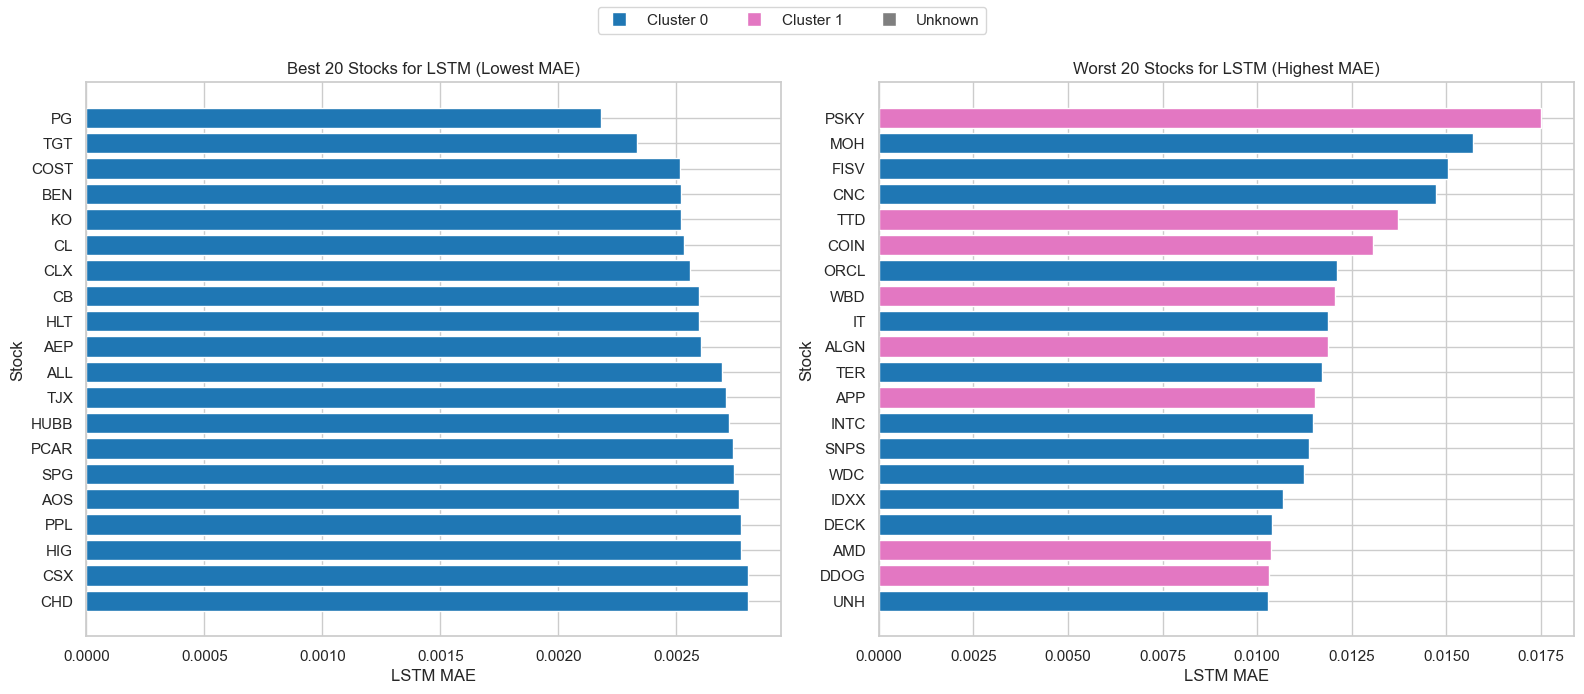

In [21]:
# Best/Worst LSTM stocks with bar color = cluster
# Blue = cluster 0, Pink = cluster 1

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

top_n = 20
min_obs = 50

# Build stock_level on the fly if it is not in memory yet.
if "stock_level" not in globals():
    work = unseen_results.copy()

    if "cluster" not in work.columns or "Cluster_name" not in work.columns:
        work = work.merge(
            cluster_map[["Symbol", "cluster", "Cluster_name"]].drop_duplicates(subset=["Symbol"]),
            on="Symbol",
            how="left"
        )

    # Add baseline predictions if unavailable.
    if "baseline_pred" not in work.columns and "ret_std_21" in work.columns:
        work["baseline_pred"] = work["ret_std_21"]

    stock_rows = []
    for sym, g in work.groupby("Symbol"):
        g_clean = g.dropna(subset=["y_true", "y_pred"]).copy()
        if len(g_clean) == 0:
            continue

        row = {
            "Symbol": sym,
            "cluster": g_clean["cluster"].iloc[0] if "cluster" in g_clean.columns else np.nan,
            "Cluster_name": g_clean["Cluster_name"].iloc[0] if "Cluster_name" in g_clean.columns else np.nan,
            "mae_lstm": mean_absolute_error(g_clean["y_true"], g_clean["y_pred"]),
            "rmse_lstm": np.sqrt(mean_squared_error(g_clean["y_true"], g_clean["y_pred"])),
            "r2_lstm": r2_score(g_clean["y_true"], g_clean["y_pred"]) if g_clean["y_true"].nunique() > 1 else np.nan,
            "n_obs": len(g_clean),
        }

        if "baseline_pred" in g_clean.columns:
            g_b = g_clean.dropna(subset=["baseline_pred"]).copy()
            if len(g_b) > 0:
                row["mae_baseline"] = mean_absolute_error(g_b["y_true"], g_b["baseline_pred"])
                row["rmse_baseline"] = np.sqrt(mean_squared_error(g_b["y_true"], g_b["baseline_pred"]))
                row["r2_baseline"] = r2_score(g_b["y_true"], g_b["baseline_pred"]) if g_b["y_true"].nunique() > 1 else np.nan

        stock_rows.append(row)

    stock_level = pd.DataFrame(stock_rows)

# Use the per-stock table.
plot_df = stock_level.copy()
plot_df = plot_df[plot_df["n_obs"] >= min_obs].copy()

if plot_df.empty:
    raise ValueError("No stocks meet the minimum observation threshold. Lower min_obs or check unseen_results.")

best = plot_df.nsmallest(top_n, "mae_lstm").sort_values("mae_lstm", ascending=False)
worst = plot_df.nlargest(top_n, "mae_lstm").sort_values("mae_lstm", ascending=True)

cluster_colors = {0: "#1f77b4", 1: "#e377c2"}  # blue / pink
default_color = "#7f7f7f"

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Best
best_colors = [cluster_colors.get(int(c), default_color) if not np.isnan(c) else default_color for c in best["cluster"]]
axes[0].barh(best["Symbol"], best["mae_lstm"], color=best_colors)
axes[0].set_title(f"Best {top_n} Stocks for LSTM (Lowest MAE)")
axes[0].set_xlabel("LSTM MAE")
axes[0].set_ylabel("Stock")

# Worst
worst_colors = [cluster_colors.get(int(c), default_color) if not np.isnan(c) else default_color for c in worst["cluster"]]
axes[1].barh(worst["Symbol"], worst["mae_lstm"], color=worst_colors)
axes[1].set_title(f"Worst {top_n} Stocks for LSTM (Highest MAE)")
axes[1].set_xlabel("LSTM MAE")
axes[1].set_ylabel("Stock")

# Shared legend
handles = [
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=cluster_colors[0], markersize=10, label='Cluster 0'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=cluster_colors[1], markersize=10, label='Cluster 1'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=default_color, markersize=10, label='Unknown'),
]
fig.legend(handles=handles, loc="upper center", ncol=3, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# Conclusions

Overall, K-means clustering successfully separated 499 S&P 500 stocks into two meaningful groups reflecting their risk profiles. The addition of cluster membership increased predictive value and improved volatility forecasting accuracy, directly addressing both research questions.

However, the model explains only 33.8% of the variance in future volatility on the test set. Most volatility remains unexplained, highlighting the inherent difficulty of forecasting financial markets. The high-low range being the strongest predictor raises a feature engineering question. Since high-low related features are used in their raw forms without log transformation or standardization, other features may have had their variability compressed during preprocessing, potentially limiting their contribution. Alternative feature representations and further tuning could be explored to address this.

The model also showed early signs of overfitting, with training halting at epoch 6 and a persistent gap between training and validation loss. The model learned patterns specific to 2021-2024 and may be less adaptable to structural shifts in later periods. Periodic retraining or a rolling window approach could improve adaptability to changing market conditions.

From a practical standpoint, the ability to distinguish between stable and high-risk stocks has real implications for risk modeling and portfolio management. Future research could explore richer feature sets incorporating macroeconomic indicators or earnings data, and more granular clustering with more than two groups to capture finer distinctions in stock behavior.

# References

Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation, 9*(8), 1735–1780. https://doi.org/10.1162/neco.1997.9.8.1735

Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and practice* (3rd ed.). OTexts. https://otexts.com/fpp3/

Scikit-learn Developers. (2024). *KMeans clustering*. https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

Scikit-learn Developers. (2024). *Permutation feature importance*. https://scikit-learn.org/stable/modules/permutation_importance.html

SR. (2024, September 13). Python for machine learning-powered volatility forecasting. Medium. https://medium.com/@deepml1818/volatility-forecasting-is-crucial-in-quantitative-finance-as-it-directly-affects-risk-management-2a9fd6387c2b

TensorFlow Developers. (2024). *Long short-term memory (LSTM) layer*. https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM



# Appendix I

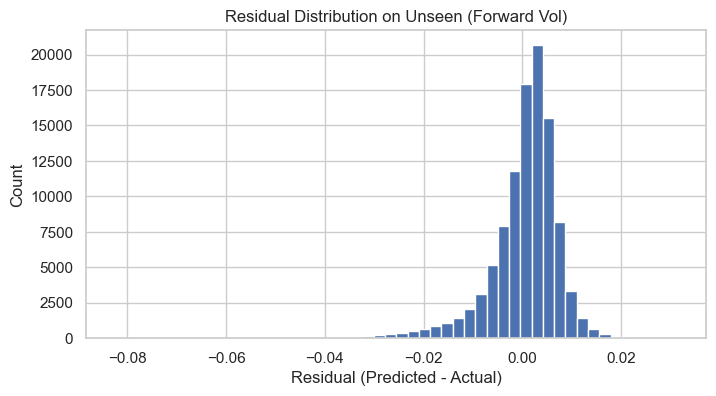

In [18]:
# Generate the unseen residual histogram (LSTM)

import matplotlib.pyplot as plt

# Predict on unseen
X_unseen_scaled = (X_unseen - feature_means) / feature_stds
y_pred_unseen = model.predict(X_unseen_scaled, verbose=0).reshape(-1) * y_std + y_mean

# Residuals: predicted - actual
residuals = (y_pred_unseen - y_unseen)

# Plot
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution on Unseen (Forward Vol)")
plt.xlabel("Residual (Predicted - Actual)")
plt.ylabel("Count")
plt.show()


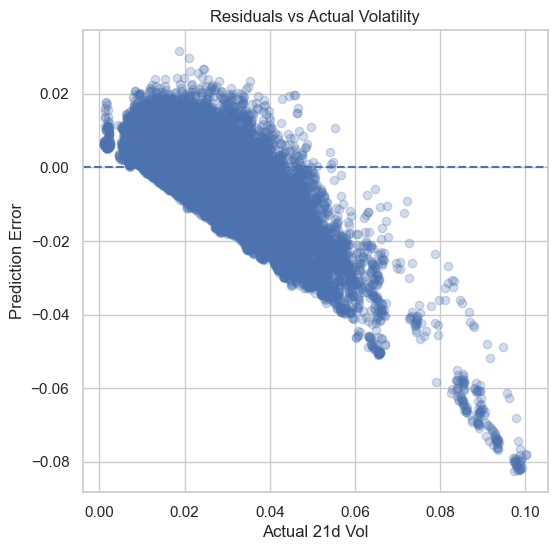

In [19]:
plt.figure(figsize=(6, 6))
error = unseen_results["y_pred"] - unseen_results["y_true"]
plt.scatter(unseen_results["y_true"], error, alpha=0.25)
plt.axhline(0, linestyle="--")
plt.xlabel("Actual 21d Vol")
plt.ylabel("Prediction Error")
plt.title("Residuals vs Actual Volatility")
plt.show()

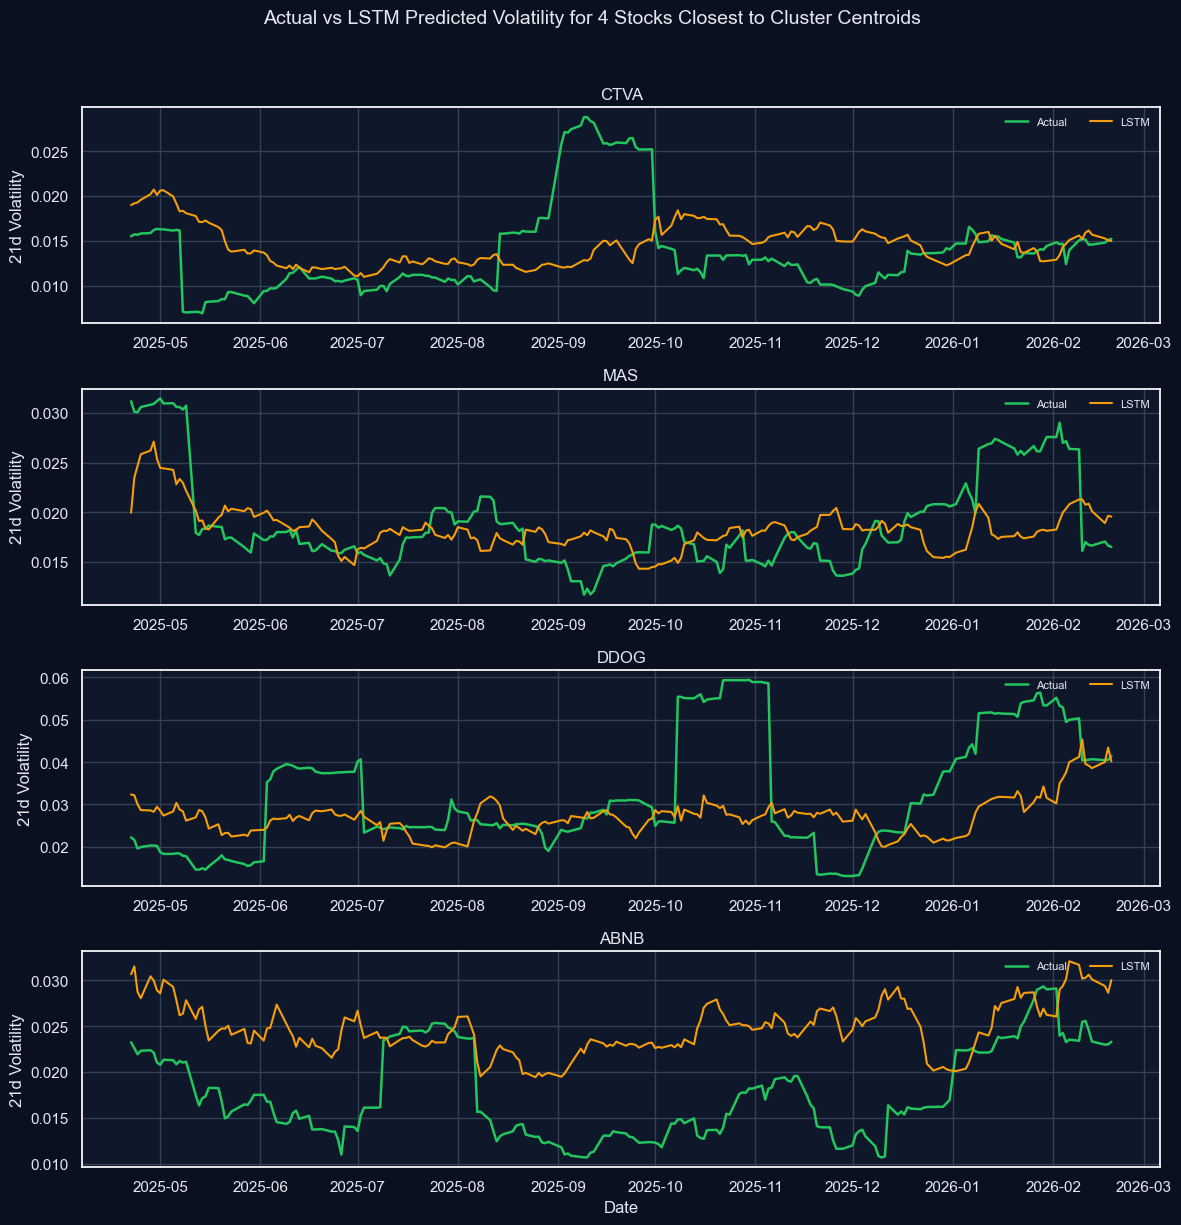

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

stocks = ["CTVA", "MAS", "DDOG", "ABNB"]

sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "figure.facecolor": "#0B1020",
    "axes.facecolor": "#0F172A",
    "savefig.facecolor": "#0B1020",
    "text.color": "#E2E8F0",
    "axes.labelcolor": "#E2E8F0",
    "xtick.color": "#E2E8F0",
    "ytick.color": "#E2E8F0",
    "grid.color": "#334155",
})

df = unseen_results.dropna(subset=["Symbol", "y_true", "y_pred"]).copy()
df = df[df["Symbol"].isin(stocks)].copy()

x_col = "Date" if "Date" in df.columns else None

fig, axes = plt.subplots(len(stocks), 1, figsize=(12, 3 * len(stocks)), sharex=False)
if len(stocks) == 1:
    axes = [axes]

for ax, sym in zip(axes, stocks):
    g = df[df["Symbol"] == sym].copy()
    if g.empty:
        ax.set_title(f"{sym} (no data)")
        ax.axis("off")
        continue

    if x_col:
        g = g.sort_values(x_col)
        x = g[x_col]
    else:
        g = g.reset_index(drop=True)
        x = g.index

    ax.plot(x, g["y_true"], color="#22C55E", lw=1.8, label="Actual")  # green
    ax.plot(x, g["y_pred"], color="#F59E0B", lw=1.5, label="LSTM")    # orange
    ax.set_title(sym)
    ax.set_ylabel("21d Volatility")
    ax.legend(loc="upper right", ncol=2, fontsize=8, frameon=False)

fig.suptitle("Actual vs LSTM Predicted Volatility for 4 " \
"Stocks Closest to Cluster Centroids", fontsize=14, y=1.02)
axes[-1].set_xlabel("Date" if x_col else "Observation")

plt.tight_layout()
plt.show()


# Appendix 2

In [ ]:
# ===== CODE APPENDIX =====